In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

In [2]:
# D2Q9 lattice velocities
c = np.array([[0, 0],    # 0  rest
              [1, 0],    # 1  east
              [0, 1],    # 2  north
              [-1, 0],   # 3  west
              [0, -1],   # 4  south
              [1, 1],    # 5  north-east
              [-1, 1],   # 6  north-west
              [-1, -1],  # 7  south-west
              [1, -1]])  # 8  south-east

# D2Q9 weights
w = np.array([4/9,
              1/9, 1/9, 1/9, 1/9,
              1/36, 1/36, 1/36, 1/36])

# Opposite directions
opp = np.array([0, 3, 4, 1, 2, 7, 8, 5, 6])

ndir = 9

In [3]:
Nx = 300
Ny = 120

# Cylinder geometry
cx_cyl = Nx // 5
cy_cyl = Ny // 2
r_cyl  = 8

# Flow parameters
U_inlet = 0.12
Re = 150

# Derived quantities
D   = 2 * r_cyl
nu  = U_inlet * D / Re
tau = 3.0 * nu + 0.5

print("Simulation parameters:")
print(f"  Grid:      {Nx} x {Ny}")
print(f"  Cylinder:  center=({cx_cyl},{cy_cyl}), r={r_cyl}, D={D}")
print(f"  Re={Re},  U_inlet={U_inlet},  nu={nu:.6f},  tau={tau:.4f}")

Simulation parameters:
  Grid:      300 x 120
  Cylinder:  center=(60,60), r=8, D=16
  Re=150,  U_inlet=0.12,  nu=0.012800,  tau=0.5384


In [4]:
@njit
def equilibrium(rho, ux, uy):
    """
    Compute the D2Q9 equilibrium distribution.
    """
    Nx, Ny = rho.shape
    feq = np.zeros((Nx, Ny, 9))
    usqr = ux**2 + uy**2

    for i in range(9):
        cu = c[i, 0] * ux + c[i, 1] * uy
        feq[:, :, i] = w[i] * rho * (
            1.0
            + 3.0 * cu
            + 4.5 * cu**2
            - 1.5 * usqr
        )
    return feq

In [5]:
x = np.arange(Nx)
y = np.arange(Ny)
X, Y = np.meshgrid(x, y, indexing='ij')

obstacle = (X - cx_cyl)**2 + (Y - cy_cyl)**2 <= r_cyl**2

In [6]:
rho_init = np.ones((Nx, Ny))
ux_init  = np.full((Nx, Ny), U_inlet)
uy_init  = np.zeros((Nx, Ny))

# Small perturbation to break symmetry
uy_init += 0.001 * U_inlet * np.sin(2.0 * np.pi * Y / Ny)

# No flow inside obstacle
ux_init[obstacle] = 0.0
uy_init[obstacle] = 0.0

In [7]:
f = equilibrium(rho_init, ux_init, uy_init)

In [8]:
plot_mode = 'velocity'   # options: 'velocity', 'vorticity', 'none'
n_steps = 30000
plot_every = 25

drag_history = np.zeros(n_steps)
lift_history = np.zeros(n_steps)

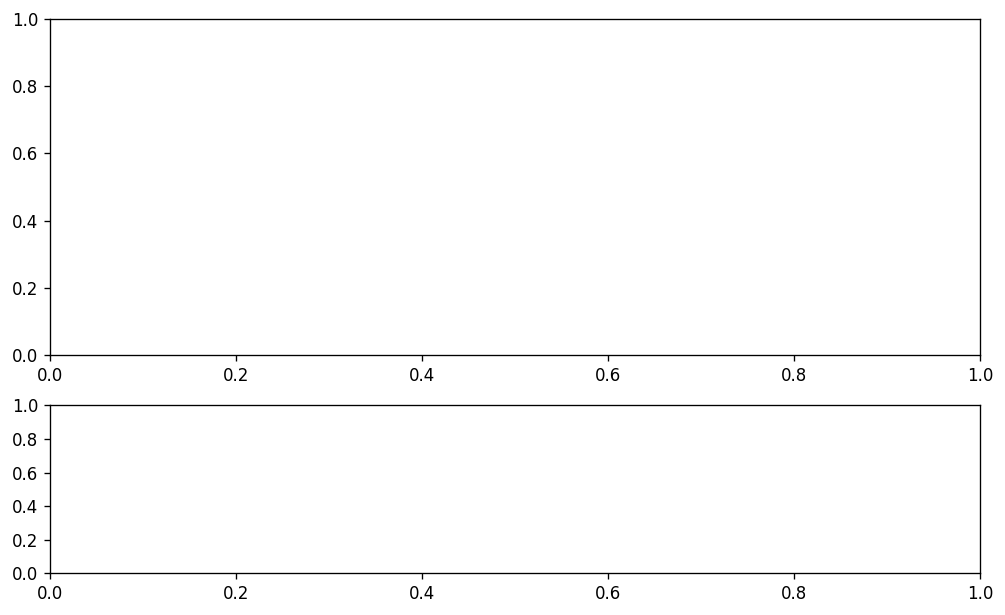

In [9]:
plt.ion()
fig, (ax_flow, ax_force) = plt.subplots(
    2, 1, figsize=(10, 6), dpi=120,
    gridspec_kw={'height_ratios': [2, 1]}
)

In [10]:
def plot_velocity(ux, uy, step):
    speed = np.sqrt(ux**2 + uy**2)
    speed[obstacle] = np.nan

    ax_flow.clear()
    ax_flow.imshow(
        speed.T,
        origin='lower',
        cmap='viridis',
        vmin=0,
        vmax=U_inlet * 2.0,
        aspect='auto',
        extent=[0, Nx, 0, Ny]
    )
    ax_flow.set_title(f"Velocity magnitude — step {step}")
    ax_flow.set_xlabel("x")
    ax_flow.set_ylabel("y")

In [11]:
def plot_vorticity(ux, uy, step):
    vorticity = (
        np.roll(uy, -1, axis=0) - np.roll(uy, 1, axis=0)
        - np.roll(ux, -1, axis=1) + np.roll(ux, 1, axis=1)
    )
    vorticity[obstacle] = np.nan

    ax_flow.clear()
    ax_flow.imshow(
        vorticity.T,
        origin='lower',
        cmap='RdBu_r',
        vmin=-0.04,
        vmax=0.04,
        aspect='auto',
        extent=[0, Nx, 0, Ny]
    )
    ax_flow.set_title(f"Vorticity field — step {step}")
    ax_flow.set_xlabel("x")
    ax_flow.set_ylabel("y")

In [12]:
def plot_field(ux, uy, step):
    if plot_mode == 'vorticity':
        plot_vorticity(ux, uy, step)
    elif plot_mode == 'velocity':
        plot_velocity(ux, uy, step)
    else:
        return

    ax_force.clear()
    s = np.arange(1, step + 1)
    ax_force.plot(s, drag_history[:step], label='Drag (Fx)', linewidth=0.8)
    ax_force.plot(s, lift_history[:step], label='Lift (Fy)', linewidth=0.8)
    ax_force.set_xlim(1, n_steps)
    ax_force.set_ylim(-0.05, 0.15)
    ax_force.set_xlabel('Timestep')
    ax_force.set_ylabel('Force')
    ax_force.legend(loc='upper right')
    ax_force.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.pause(0.01)

In [ ]:
print(f"\nRunning {n_steps} timesteps ...")

for step in range(1, n_steps + 1):

    # 1. Macroscopic quantities
    rho = np.sum(f, axis=2)
    ux  = np.sum(f * c[:, 0], axis=2) / rho
    uy  = np.sum(f * c[:, 1], axis=2) / rho

    # 2. Collision
    feq   = equilibrium(rho, ux, uy)
    f_out = f - (f - feq) / tau

    # 3. Bounce-back and force computation
    Fx, Fy = 0.0, 0.0
    for i in range(ndir):
        Fx += c[i, 0] * np.sum(f_out[obstacle, i] + f_out[obstacle, opp[i]])
        Fy += c[i, 1] * np.sum(f_out[obstacle, i] + f_out[obstacle, opp[i]])
        f_out[obstacle, i] = f[obstacle, opp[i]]

    drag_history[step - 1] = Fx
    lift_history[step - 1] = Fy

    # 4. Streaming
    for i in range(ndir):
        f[:, :, i] = np.roll(f_out[:, :, i], shift=c[i, 0], axis=0)
        f[:, :, i] = np.roll(f[:, :, i],     shift=c[i, 1], axis=1)

    # 5. Outlet BC
    f[-1, :, :] = f[-2, :, :]

    # 6. Inlet BC (Zou-He)
    rho_in = (
        (f[0, :, 0] + f[0, :, 2] + f[0, :, 4])
        + 2.0 * (f[0, :, 3] + f[0, :, 6] + f[0, :, 7])
    ) / (1.0 - U_inlet)

    f[0, :, 1] = f[0, :, 3] + (2.0/3.0) * rho_in * U_inlet
    f[0, :, 5] = (
        f[0, :, 7]
        - 0.5 * (f[0, :, 2] - f[0, :, 4])
        + (1.0/6.0) * rho_in * U_inlet
    )
    f[0, :, 8] = (
        f[0, :, 6]
        + 0.5 * (f[0, :, 2] - f[0, :, 4])
        + (1.0/6.0) * rho_in * U_inlet
    )

    # 7. Plot and progress
    if step % plot_every == 0:
        plot_field(ux, uy, step)

    if step % 1000 == 0:
        avg_rho = np.mean(rho[~obstacle])
        print(f"  Step {step:>6d}/{n_steps}  |  avg density = {avg_rho:.6f}")


Running 30000 timesteps ...
  Step   1000/30000  |  avg density = 1.000496
  Step   2000/30000  |  avg density = 0.998416
  Step   3000/30000  |  avg density = 0.997446
  Step   4000/30000  |  avg density = 0.996556
  Step   5000/30000  |  avg density = 0.995991
  Step   6000/30000  |  avg density = 0.995788
  Step   7000/30000  |  avg density = 0.996234
  Step   8000/30000  |  avg density = 0.997663
  Step   9000/30000  |  avg density = 0.998429
  Step  10000/30000  |  avg density = 0.997862
  Step  11000/30000  |  avg density = 0.997841


In [15]:
print("\nSimulation complete.")
plt.ioff()
plt.show()


Simulation complete.
